# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2025**


----

# Trabajo práctico entregable - parte 2


Trabajaremos con la base de datos de `melb_data` presentada a continuación.

In [191]:
import matplotlib.pyplot as plt
import numpy as np
import pandas

import seaborn as sns
sns.set_context('talk')

In [192]:
# Acá deberían leer el conjunto de datos que ya tienen.
melb_df = pandas.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')
melb_df[:3]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


## Ejercicio 1: Encoding

1. Seleccionar todas las filas y columnas del conjunto de datos, **excepto** `BuildingArea` y `YearBuilt`.

2. Aplicar una codificación One-hot encoding a cada fila, para las variables categóricas. Si lo consideran necesario, pueden volver a reducir el número de categorías únicas.

Algunas opciones:
  1. Utilizar `OneHotEncoder` junto con el parámetro `categories` para las variables categóricas y luego usar `numpy.hstack` para concatenar el resultado con las variables numéricas.
  2. `DictVectorizer` con algunos pasos de pre-proceso previo.

Recordar también que el atributo `pandas.DataFrame.values` permite acceder a la matriz de numpy subyacente a un DataFrame.


In [193]:
# Librerías necesarias
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder

Filtramos outliers de algunas de las columnas que nos servirán más adelante.

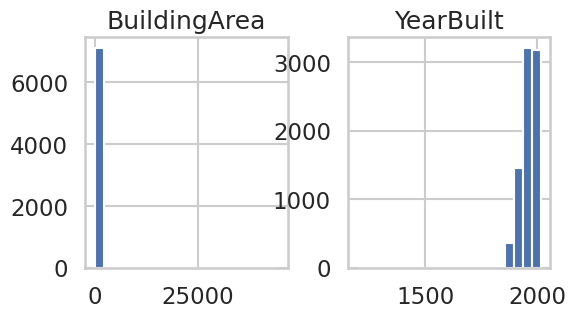

In [194]:
melb_df[['BuildingArea','YearBuilt']].hist(bins=20, figsize=(6, 3));

In [195]:
q99 = melb_df['BuildingArea'].quantile(0.99)
q01 = melb_df['YearBuilt'].quantile(0.01)
melb_df2 = melb_df[(melb_df['BuildingArea']<q99) | (melb_df['BuildingArea'].isna())]
melb_df2 = melb_df2[(melb_df2['YearBuilt']>q01) | (melb_df2['YearBuilt'].isna())]

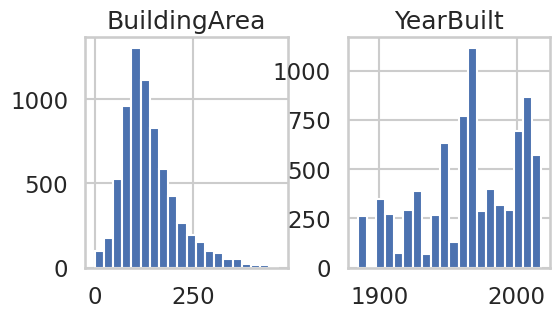

In [196]:
melb_df2[['BuildingArea','YearBuilt']].hist(bins=20, figsize=(6, 3));

Ahora que ya tengo los outliers eliminados puedo continuar.

In [197]:
# Quitamos columnas solicitadas
df = melb_df2.drop(columns=['BuildingArea', 'YearBuilt', 'CouncilArea']) #Agrego CouncilArea por que tenía nulos

Analizemos la información presente en las columnas por un segundo:

In [198]:
df.head(3)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,2.0,1.0,1.0,202.0,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,2.0,1.0,0.0,156.0,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,0.0,134.0,-37.8093,144.9944,Northern Metropolitan,4019.0


El parámetro fecha debe ser considerado del formato *datetime*. Es prácticamente numérico.

In [201]:
# Asegurarse de que sea datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [202]:
df.head(3)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-03-12,2.5,3067.0,2.0,1.0,1.0,202.0,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-04-02,2.5,3067.0,2.0,1.0,0.0,156.0,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-04-03,2.5,3067.0,3.0,2.0,0.0,134.0,-37.8093,144.9944,Northern Metropolitan,4019.0


Ahora si, puedo pasar a identificar columnas categóricas y numéricas.

In [203]:
# Identifico columnas numéricas y categóricas
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

In [204]:
print(f"Columnas categóricas: {categorical_cols}")

Columnas categóricas: ['Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Regionname']


In [205]:
# Disminuimos la dimensionalidad del problema, tomando el Top 5 de clases
for col in categorical_cols:
    df[col] = df[col].astype(str)
    top_5 = df[col].value_counts().nlargest(5).index
    df[col] = df[col].where(df[col].isin(top_5), 'Other')

Realizo el One-Hot Encoding.

In [206]:
# Inicializo el encoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [207]:
# Realizo el ajuste
X_cat = encoder.fit_transform(df[categorical_cols])

In [208]:
# Obtengo un nuevo nombre para cada columnas codificada
encoded_col_names = [
    f"{col}={val}" for col, vals in zip(categorical_cols, encoder.categories_) for val in vals
]

In [209]:
# Concateno las variables categóricas codificadas con las numéricas
X_num = df[numerical_cols].values
X = np.hstack([X_cat, X_num])
final_columns = encoded_col_names + numerical_cols

In [210]:
# Genero el dataframe con las variables categóricas codificadas
df_encoded = pd.DataFrame(X, columns=final_columns)

In [211]:
df_encoded.head(5)

,Suburb=Bentleigh East,Suburb=Essendon,Suburb=Other,Suburb=Preston,Suburb=Reservoir,Suburb=Richmond,Address=13 Robinson St,Address=14 Arthur St,Address=2 Bruce St,Address=36 Aberfeldie St,...,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,Lattitude,Longtitude,Propertycount
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1480000.0,2.5,3067.0,2.0,1.0,1.0,202.0,-37.7996,144.9984,4019.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1035000.0,2.5,3067.0,2.0,1.0,0.0,156.0,-37.8079,144.9934,4019.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1465000.0,2.5,3067.0,3.0,2.0,0.0,134.0,-37.8093,144.9944,4019.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,850000.0,2.5,3067.0,3.0,2.0,1.0,94.0,-37.7969,144.9969,4019.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1600000.0,2.5,3067.0,3.0,1.0,2.0,120.0,-37.8072,144.9941,4019.0


Es interesante notar que los tamaños de los dataframe inicial respecto al codificado es enorme, y además el problema principal es que genera matrices dispersas, las cuales generan problemas de uso ineficiente de memoria, tiempo de computo, etc.

In [212]:
print(f"Tamaño original del dataframe: {df.shape}")
print(f"Tamaño del dataframe codificado por One-Hot Encoding: {df_encoded.shape}")

Tamaño original del dataframe: (13412, 18)
Tamaño del dataframe codificado por One-Hot Encoding: (13412, 43)


Ha generado una columna por cada variable categórica.

## Ejercicio 2: Imputación por KNN

En el teórico se presentó el método `IterativeImputer` para imputar valores faltantes en variables numéricas. Sin embargo, los ejemplos presentados sólo utilizaban algunas variables numéricas presentes en el conjunto de datos. En este ejercicio, utilizaremos la matriz de datos codificada para imputar datos faltantes de manera más precisa.

1. Agregue a la matriz obtenida en el punto anterior las columnas `YearBuilt` y `BuildingArea`.
2. Aplique una instancia de `IterativeImputer` con un estimador `KNeighborsRegressor` para imputar los valores de las variables. ¿Es necesario estandarizar o escalar los datos previamente?
3. Realice un gráfico mostrando la distribución de cada variable antes de ser imputada, y con ambos métodos de imputación.

In [213]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.neighbors import KNeighborsRegressor

In [214]:
# Hacemos copia del DataFrame
df_encoded_mice = df_encoded.copy(deep=True)

In [215]:
# Seleccionamos las columnas originales desde el melb_df
cols_nulas = melb_df2[['YearBuilt', 'BuildingArea']]

# Concatenamos horizontalmente (axis=1)
df_encoded_full = pd.concat([df_encoded_mice, cols_nulas], axis=1)


In [216]:
# Imputador con KNN
mice_imputer = IterativeImputer(random_state=10, estimator=KNeighborsRegressor(n_neighbors=5))

In [217]:
# Aplicar imputación
result = mice_imputer.fit_transform(df_encoded_full);

/usr/local/lib/python3.11/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [218]:
 # Reemplazamos los datos generados
 df_encoded_full.iloc[:,:] = result[:,:]

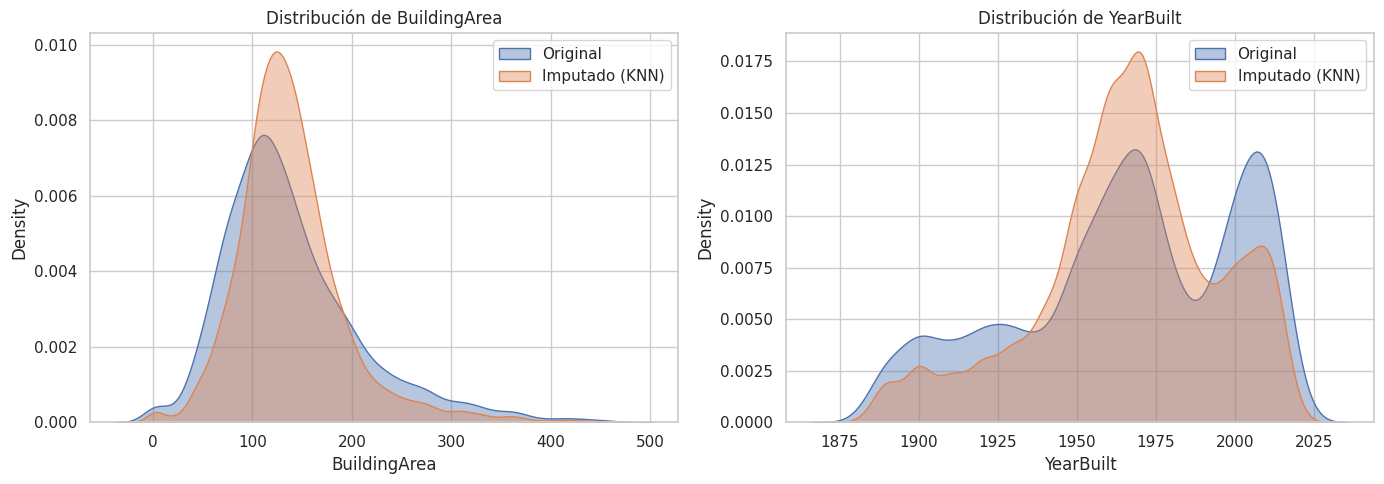

In [219]:
# Gráfico
sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# =======================
# BuildingArea
# =======================
sns.kdeplot(
    data=melb_df2, x='BuildingArea', label='Original', ax=axes[0], fill=True, alpha=0.4
)
sns.kdeplot(
    data=df_encoded_full, x='BuildingArea', label='Imputado (KNN)', ax=axes[0], fill=True, alpha=0.4
)
axes[0].set_title('Distribución de BuildingArea')
axes[0].legend()

# =======================
# YearBuilt
# =======================
sns.kdeplot(
    data=melb_df2, x='YearBuilt', label='Original', ax=axes[1], fill=True, alpha=0.4
)
sns.kdeplot(
    data=df_encoded_full, x='YearBuilt', label='Imputado (KNN)', ax=axes[1], fill=True, alpha=0.4
)
axes[1].set_title('Distribución de YearBuilt')
axes[1].legend()
plt.tight_layout()
plt.show()


En el gráfico se puede observar como se han agregado datos, no es tan burdo como solo agregar un valor fijo como la media o el valor que mayor repetición tiene. <br>
Sin embargo, la utilización de este tipo de técnicas, sin dudas genera un bias en los datos.

## Ejercicio 3: Reducción de dimensionalidad.

Utilizando la matriz obtenida en el ejercicio anterior:
1. Aplique `PCA` para obtener $n$ componentes principales de la matriz, donde `n = min(20, X.shape[0])`. ¿Es necesario estandarizar o escalar los datos?
2. Seleccione las primeras $2$ columnas de la matriz transformada para agregar como nuevas características al conjunto de datos. Realizar un gráfico de la componente principal 1 vs la componente principal 2 (pca1-pca2).
3. Transformar nuevamente el conjunto de datos procesado en un `pandas.DataFrame` y guardarlo en un archivo.

`¿Es necesario estandarizar o escalar los datos?` : Sí, debido a que PCA se basa en la varianza de los datos. Si una variable tiene un rango mucho mayor que otro, dominará las componentes principales.

In [220]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

In [221]:
# Escalamos los datos imputados y codificados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded_full)

In [222]:
# Aplicamos PCA (n = min(20, X.shape[1]))
n_components = min(20, X_scaled.shape[1])
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

In [223]:
# Añadir las primeras dos componentes al DataFrame original
df_with_pca = df_encoded_full.copy()
df_with_pca['pca1'] = X_pca[:, 0]
df_with_pca['pca2'] = X_pca[:, 1]

In [240]:
# Cargas del PCA
loadings = pd.DataFrame(
    pca.components_.T,
    index=df_encoded_full.columns,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

# 10 variables que más influyen en PCA 1
loadings['PC1'].abs().sort_values(ascending=False).head(10)

,PC1
Rooms,0.402785
Bedroom2,0.398342
Type=u,0.308392
Bathroom,0.302248
Type=h,0.296348
Price,0.295491
Car,0.243593
Distance,0.234007
Regionname=Northern Metropolitan,0.176584
Longtitude,0.163131


In [249]:
# 10 variables que más influyen en PCA 2
loadings['PC2'].abs().sort_values(ascending=False).head(10)

,PC2
Lattitude,0.393199
Regionname=Southern Metropolitan,0.388626
Postcode,0.329204
Longtitude,0.269259
Regionname=Northern Metropolitan,0.250669
Type=h,0.246045
Type=u,0.244255
Regionname=Western Metropolitan,0.243576
SellerG=Nelson,0.210890
Rooms,0.176735


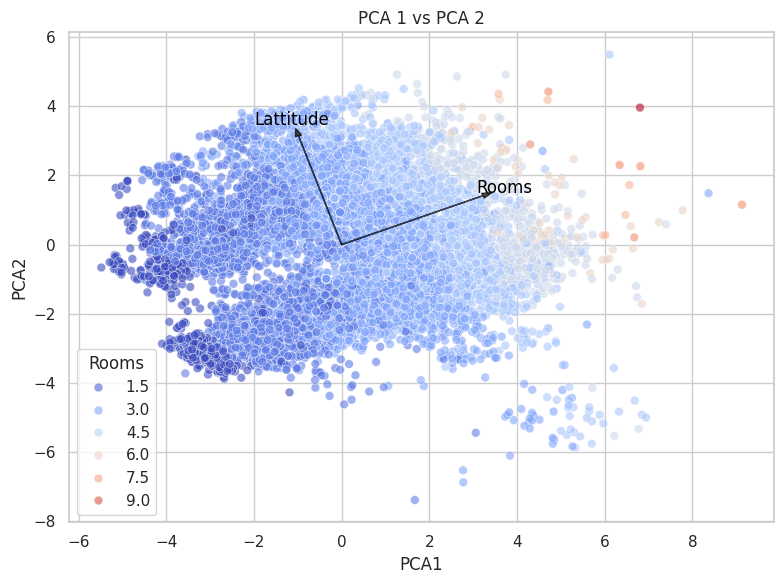

In [251]:
# Selecciono las variables que presentan un mayor peso para representarlas
vars_to_plot = ['Rooms','Lattitude']
scale = 8

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_with_pca, x='pca1', y='pca2', hue='Rooms', palette='coolwarm', s=40, alpha=0.6)

for var in vars_to_plot:
    x_vec = loadings.loc[var, 'PC1'] * scale
    y_vec = loadings.loc[var, 'PC2'] * scale
    plt.arrow(0, 0, x_vec, y_vec, color='black', alpha=0.7, head_width=0.15)
    plt.text(x_vec * 1.15, y_vec * 1.15, var, color='black', ha='center', va='center')

plt.title('PCA 1 vs PCA 2')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.grid(True)
plt.tight_layout()
plt.show()


En este gráfico se pueden observar, la variación del parámetro "Rooms" alrededor del PCA1. También se pueden encontrar que los valores atípicos se encuentran alejados del centro.

Se puede interpretar este gráfico de PCA1 vs PCA2 como una relación no demasiado clusterizada, donde no se pueden encontrar subgrupos.

Si tenemos en cuenta los pesos principales de PCA1, podemos observar la dirección del vector de su peso principal, el cual es Rooms. Mientras que para PCA2, podemos observar la dirección de su peso principal el cual es Lattitude.

In [226]:
# Guardamos el dataframe en un archivo csv
df_with_pca.to_csv("melb_data_processed_with_pca.csv", index=False)
from google.colab import files
files.download("melb_data_processed_with_pca.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Ejercicio 4: Documentación

En un documento `.pdf` o `.md` realizar un reporte de las operaciones que realizaron para obtener el conjunto de datos final. Se debe incluir:
  1. Criterios de exclusión (o inclusión) de filas y de imputación de datos faltantes
  2. Interpretación de las columnas presentes
  3. Todas las transofrmaciones realizadas
  4. Análisis breve de lo observado mediante PCA.

Este documento es de uso técnico exclusivamente, y su objetivo es permitir que otres desarrolladores puedan reproducir los mismos pasos y obtener el mismo resultado. Debe ser detallado pero consiso. Por ejemplo:

```
  ## Criterios de exclusión de ejemplos
  1. Se eliminan ejemplos donde el año de construcción es previo a 1900

  ## Características seleccionadas
  ### Características categóricas
  1. Type: tipo de propiedad. 3 valores posibles
  2. ...
  Todas las características categóricas fueron codificadas con un
  método OneHotEncoding utilizando como máximo sus 30 valores más
  frecuentes.
  
  ### Características numéricas
  1. Rooms: Cantidad de habitaciones
  2. Distance: Distancia al centro de la ciudad.
  3. airbnb_mean_price: Se agrega el precio promedio diario de
     publicaciones de la plataforma AirBnB en el mismo código
     postal. [Link al repositorio con datos externos].

  ### Transformaciones:
  1. Todas las características numéricas fueron estandarizadas.
  2. La columna `Suburb` fue imputada utilizando el método ...
  3. Las columnas `YearBuilt` y ... fueron imputadas utilizando el
     algoritmo ...
  4. ...

  ### Datos aumentados
  1. Se agregan las 5 primeras columnas obtenidas a través del
     método de PCA, aplicado sobre el conjunto de datos
     totalmente procesado.
```
